# γ-CKLSearch vs GAUSSSEARCH — 3D belief evolution

Side-by-side visualization: for the same target, watch both algorithms' beliefs evolve over the same query steps.

- **Left panel**: γ-CKLSearch's discrete posterior P over the 600 items. Point size/opacity = P.
- **Right panel**: GAUSSSEARCH's Gaussian belief (μ, Σ). Ellipsoid at 2σ.
- Both projected to the same 3D PCA basis.

Run from `scenery-search/notebooks/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.stats import norm
from sklearn.decomposition import PCA
from pathlib import Path

DATA = Path("../data")
NPZ = DATA / "scenery_embedding.npz"
assert NPZ.exists(), f"embeddings not found at {NPZ}"

data = np.load(NPZ, allow_pickle=True)
E_work = data["E_work"]
labels = np.array([str(l) for l in data["labels"]])
X_scale = float(E_work.std(axis=0).mean())
X = E_work / X_scale
n, d = X.shape
print(f"X shape: {X.shape}, X_scale: {X_scale:.4f}")

X shape: (600, 10), X_scale: 0.1250


## Fit PCA once — used to project everything to 3D

In [2]:
pca = PCA(n_components=3, random_state=0)
X3 = pca.fit_transform(X)
print(f"explained variance ratio: {pca.explained_variance_ratio_}")
print(f"cumulative: {pca.explained_variance_ratio_.cumsum()}")

# color per class for the scatter
CLASSES = sorted(set(labels))
CLASS_COLORS = {cls: c for cls, c in zip(
    CLASSES,
    ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
)}
point_colors = np.array([CLASS_COLORS[l] for l in labels])

explained variance ratio: [0.268319   0.16400762 0.12795952]
cumulative: [0.268319   0.4323266  0.56028616]


## Algorithms with per-step trace

Return the belief state at every step so we can replay it.

In [3]:
SIGMA_EPS = 0.05
GAMMA_VAL = 5.0
R_GCKL = 2.0


def sample_mirror_gckl(X, P, used, r=2.0, eps=1e-12):
    mu = (P[:, None] * X).sum(axis=0)
    diff = X - mu
    Sigma = (P[:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    lam_max = max(eigvals[-1], eps)
    v_max = eigvecs[:, -1]
    z1 = mu + r * np.sqrt(lam_max) * v_max
    z2 = mu - r * np.sqrt(lam_max) * v_max

    def pick(z, excl):
        d2 = np.sum((X - z) ** 2, axis=1)
        score = d2 / (P + eps)
        for u in excl:
            score[u] = np.inf
        return int(np.argmin(score))

    i = pick(z1, used)
    j = pick(z2, used | {i})
    return i, j


def gamma_ckl_prob(x_i, x_j, x_t, gamma):
    d_i = np.linalg.norm(x_i - x_t)
    d_j = np.linalg.norm(x_j - x_t)
    if d_i == 0: return 1.0
    if d_j == 0: return 0.0
    return (d_j ** gamma) / (d_i ** gamma + d_j ** gamma)


def bayes_update(X, P, i, j, y, gamma, eps=1e-12):
    d_i = np.linalg.norm(X - X[i], axis=1)
    d_j = np.linalg.norm(X - X[j], axis=1)
    d_i_g = d_i ** gamma
    d_j_g = d_j ** gamma
    denom = d_i_g + d_j_g + eps
    likelihood = (d_j_g if y == i else d_i_g) / denom
    P_new = P * likelihood
    Z = P_new.sum()
    return P_new / Z if Z > eps else P.copy()


def gamma_ckl_trace(X, target_idx, gamma, r, max_queries, seed):
    """Run γ-CKLSearch and return the full trajectory of P."""
    rng = np.random.default_rng(seed)
    n = len(X)
    P = np.ones(n) / n
    used = set()
    x_t = X[target_idx]
    trajectory = [{"step": 0, "P": P.copy(), "query": None, "picked": None}]

    for step in range(max_queries):
        i, j = sample_mirror_gckl(X, P, used, r=r)
        used |= {i, j}
        p_i = gamma_ckl_prob(X[i], X[j], x_t, gamma)
        y_idx = 0 if rng.random() < p_i else 1
        y = i if y_idx == 0 else j
        if target_idx in (i, j):
            trajectory.append({
                "step": step + 1, "P": P.copy(),
                "query": (i, j), "picked": y, "found": True,
            })
            return trajectory
        P = bayes_update(X, P, i, j, y, gamma)
        trajectory.append({
            "step": step + 1, "P": P.copy(),
            "query": (i, j), "picked": y, "found": False,
        })
    return trajectory


def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    w = x_j - x_i
    b = 0.5 * (np.dot(x_j, x_j) - np.dot(x_i, x_i))
    sign = -1.0 if y == 0 else 1.0
    v = sign * w
    c = sign * b
    v_Sigma_v = float(v @ Sigma @ v)
    denom = np.sqrt(v_Sigma_v + sigma_eps ** 2)
    z = (v @ mu - c) / denom
    phi = norm.pdf(z); Phi = norm.cdf(z)
    if Phi < 1e-12:
        return mu.copy(), Sigma.copy()
    alpha = phi / Phi
    beta = alpha * (alpha + z)
    Sigma_v = Sigma @ v
    mu_new = mu + (alpha / denom) * Sigma_v
    Sigma_new = Sigma - (beta / (v_Sigma_v + sigma_eps ** 2)) * np.outer(Sigma_v, Sigma_v)
    return mu_new, Sigma_new


def sample_mirror_gs(mu, Sigma, X, used, eps=1e-12):
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    lam_max = max(eigvals[-1], eps)
    v_max = eigvecs[:, -1]
    z1 = mu + np.sqrt(lam_max) * v_max
    z2 = mu - np.sqrt(lam_max) * v_max

    def nearest(z, excl):
        d2 = np.sum((X - z) ** 2, axis=1)
        for u in excl:
            d2[u] = np.inf
        return int(np.argmin(d2))

    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    return i, j


def gauss_trace(X, target_idx, sigma_eps, max_queries, seed, oracle_gamma=None):
    """Run GAUSSSEARCH and return the full trajectory of (μ, Σ)."""
    rng = np.random.default_rng(seed)
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    x_t = X[target_idx]
    trajectory = [{"step": 0, "mu": mu.copy(), "Sigma": Sigma.copy(),
                    "query": None, "picked": None}]

    for step in range(max_queries):
        i, j = sample_mirror_gs(mu, Sigma, X, used)
        used |= {i, j}
        # answer via same γ-CKL oracle so this is a fair 1:1 comparison
        if oracle_gamma is not None:
            p_i = gamma_ckl_prob(X[i], X[j], x_t, oracle_gamma)
        else:
            d_i2 = np.sum((X[i] - x_t) ** 2)
            d_j2 = np.sum((X[j] - x_t) ** 2)
            p_i = norm.cdf((d_j2 - d_i2) / (2 * sigma_eps + 1e-12))
        y = 0 if rng.random() < p_i else 1
        picked = i if y == 0 else j
        if target_idx in (i, j):
            trajectory.append({
                "step": step + 1, "mu": mu.copy(), "Sigma": Sigma.copy(),
                "query": (i, j), "picked": picked, "found": True,
            })
            return trajectory
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
        trajectory.append({
            "step": step + 1, "mu": mu.copy(), "Sigma": Sigma.copy(),
            "query": (i, j), "picked": picked, "found": False,
        })
    return trajectory

## Pick a target and run both

Pick one target we know γ-CKL handled cleanly. Both algorithms answered by the SAME γ-CKL oracle so it's a fair fight.

In [4]:
# pick a target — feel free to change class
TARGET_CLASS = "mountain"
mask = np.array([l == TARGET_CLASS for l in labels])
target_indices_of_class = np.where(mask)[0]
target_idx = int(target_indices_of_class[3])  # 4th image of the class
print(f"target idx {target_idx}, class '{labels[target_idx]}'")

MAX_Q = 25
gckl_traj = gamma_ckl_trace(X, target_idx, gamma=GAMMA_VAL, r=R_GCKL,
                              max_queries=MAX_Q, seed=0)
gs_traj = gauss_trace(X, target_idx, sigma_eps=SIGMA_EPS,
                       max_queries=MAX_Q, seed=0, oracle_gamma=GAMMA_VAL)

print(f"γ-CKL: {len(gckl_traj)-1} queries, found={gckl_traj[-1].get('found', False)}")
print(f"GAUSS: {len(gs_traj)-1} queries, found={gs_traj[-1].get('found', False)}")

target idx 303, class 'mountain'
γ-CKL: 15 queries, found=True
GAUSS: 6 queries, found=True


## Plot side-by-side at selected steps

Left: γ-CKL, point sizes ∝ P (bigger = higher posterior).
Right: GAUSSSEARCH, blue point = μ projected, blue ellipsoid = 2σ region.
Target marked with a red star in both.

showing steps: [0, 5, 10, 15]


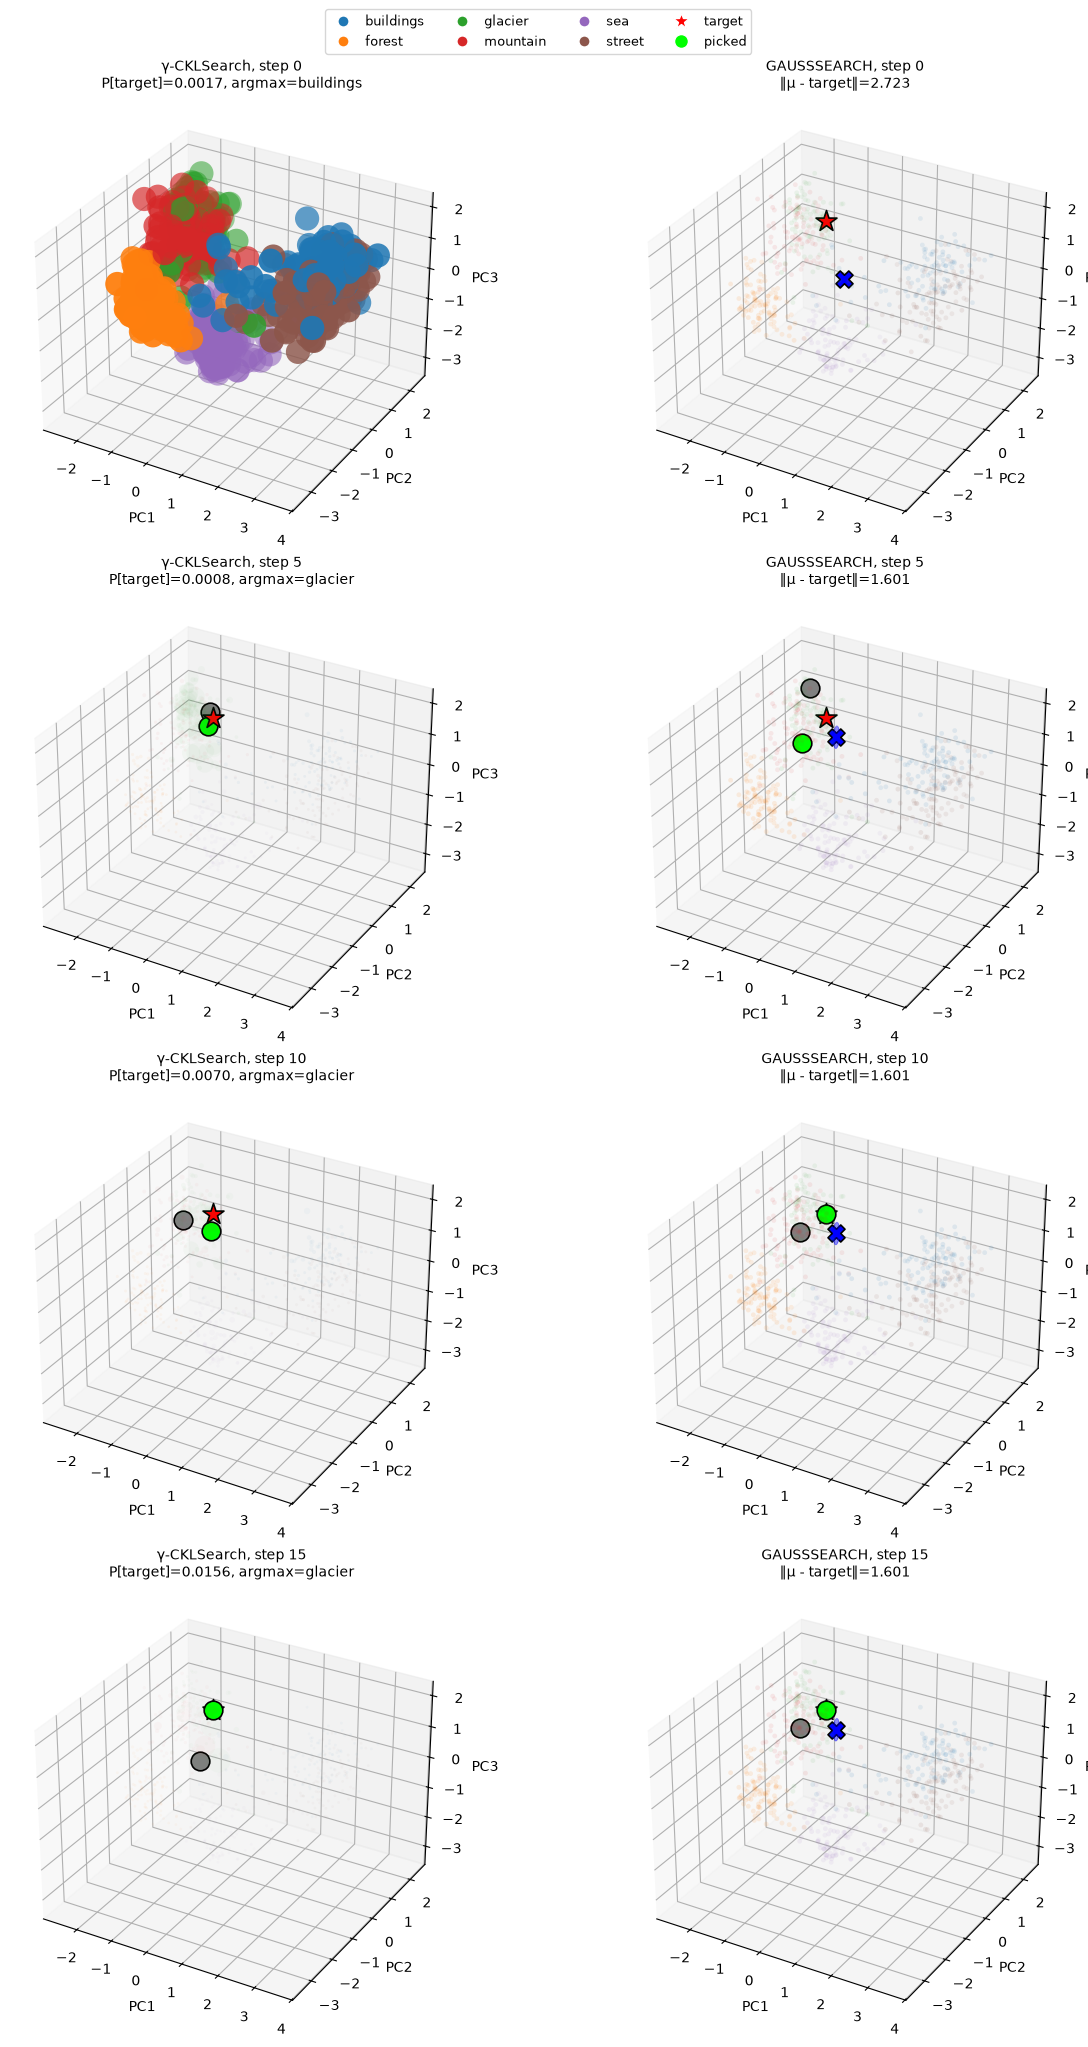

In [5]:
def ellipsoid_from_gaussian(mu, Sigma, pca, n_sigma=2.0, n_pts=20):
    """Project a 2σ ellipsoid of a d-dim Gaussian into the 3D PCA basis."""
    # A d-dim ellipsoid at n_sigma standard deviations. First we do eig-decomp
    # of Sigma to get axes and radii in the original space, then project the
    # surface into PCA space.
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    eigvals = np.clip(eigvals, 1e-12, None)
    radii = n_sigma * np.sqrt(eigvals)

    # Sample points on a unit sphere in d dims — approximate the ellipsoid
    # surface by top-3-axis ellipsoid, project the samples through PCA.
    # For high d we just take the top-3 axes of Σ.
    top_axes = eigvecs[:, -3:]         # (d, 3)
    top_radii = radii[-3:]             # (3,)

    u = np.linspace(0, 2 * np.pi, n_pts)
    v = np.linspace(0, np.pi, n_pts)
    U, V = np.meshgrid(u, v)
    a, b, c = top_radii
    xs = a * np.cos(U) * np.sin(V)
    ys = b * np.sin(U) * np.sin(V)
    zs = c * np.cos(V)
    pts_local = np.stack([xs.ravel(), ys.ravel(), zs.ravel()], axis=1)  # (n_pts², 3)

    # transform back into d-dim world coords, then project via PCA
    pts_world = pts_local @ top_axes.T + mu
    pts_3d = pca.transform(pts_world)
    return pts_3d.reshape(n_pts, n_pts, 3)


def plot_side_by_side(step_indices, gckl_traj, gs_traj, X3, target_idx,
                       labels, point_colors, pca, save_path=None):
    n_steps = len(step_indices)
    fig = plt.figure(figsize=(14, 5 * n_steps))

    target_xyz = X3[target_idx]

    for row, step in enumerate(step_indices):
        gc = gckl_traj[min(step, len(gckl_traj) - 1)]
        gs = gs_traj[min(step, len(gs_traj) - 1)]
        P = gc["P"]

        # --- left: γ-CKL ---
        ax1 = fig.add_subplot(n_steps, 2, 2 * row + 1, projection="3d")
        # size proportional to P, opacity too
        sizes = 4 + 300 * P / (P.max() + 1e-12)
        alphas = 0.15 + 0.85 * (P / (P.max() + 1e-12)) ** 0.5
        ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2],
                     s=sizes, c=point_colors, alpha=alphas.mean(),
                     edgecolors="none")
        ax1.scatter(target_xyz[0], target_xyz[1], target_xyz[2],
                     s=250, c="red", marker="*", edgecolors="black",
                     linewidths=1.2, label="target")
        if gc["query"] is not None:
            qi, qj = gc["query"]
            picked = gc["picked"]
            ax1.scatter(X3[qi, 0], X3[qi, 1], X3[qi, 2],
                         s=180, c="lime" if picked == qi else "gray",
                         marker="o", edgecolors="black", linewidths=1.2)
            ax1.scatter(X3[qj, 0], X3[qj, 1], X3[qj, 2],
                         s=180, c="lime" if picked == qj else "gray",
                         marker="o", edgecolors="black", linewidths=1.2)
        argmax_idx = int(np.argmax(P))
        ax1.set_title(f"γ-CKLSearch, step {step}\n"
                       f"P[target]={P[target_idx]:.4f}, argmax={labels[argmax_idx]}",
                       fontsize=10)
        ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2"); ax1.set_zlabel("PC3")

        # --- right: GAUSSSEARCH ---
        ax2 = fig.add_subplot(n_steps, 2, 2 * row + 2, projection="3d")
        ax2.scatter(X3[:, 0], X3[:, 1], X3[:, 2],
                     s=12, c=point_colors, alpha=0.35, edgecolors="none")
        ax2.scatter(target_xyz[0], target_xyz[1], target_xyz[2],
                     s=250, c="red", marker="*", edgecolors="black",
                     linewidths=1.2, label="target")

        mu_3d = pca.transform(gs["mu"].reshape(1, -1))[0]
        ax2.scatter(mu_3d[0], mu_3d[1], mu_3d[2],
                     s=150, c="blue", marker="X", edgecolors="black",
                     linewidths=1.2, label="μ")

        # 2σ ellipsoid
        ell = ellipsoid_from_gaussian(gs["mu"], gs["Sigma"], pca, n_sigma=2.0)
        ax2.plot_wireframe(ell[..., 0], ell[..., 1], ell[..., 2],
                            color="blue", alpha=0.15, linewidth=0.5)

        if gs["query"] is not None:
            qi, qj = gs["query"]
            picked = gs["picked"]
            ax2.scatter(X3[qi, 0], X3[qi, 1], X3[qi, 2],
                         s=180, c="lime" if picked == qi else "gray",
                         marker="o", edgecolors="black", linewidths=1.2)
            ax2.scatter(X3[qj, 0], X3[qj, 1], X3[qj, 2],
                         s=180, c="lime" if picked == qj else "gray",
                         marker="o", edgecolors="black", linewidths=1.2)

        dist_to_target = np.linalg.norm(gs["mu"] - X[target_idx])
        ax2.set_title(f"GAUSSSEARCH, step {step}\n"
                       f"‖μ - target‖={dist_to_target:.3f}",
                       fontsize=10)
        ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")

    # class legend in the very last axes
    handles = [plt.Line2D([0], [0], marker="o", color="w",
                            markerfacecolor=CLASS_COLORS[cls], markersize=8, label=cls)
                for cls in CLASSES]
    handles.append(plt.Line2D([0], [0], marker="*", color="w",
                                markerfacecolor="red", markersize=12, label="target"))
    handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                markerfacecolor="lime", markersize=10, label="picked"))
    fig.legend(handles=handles, loc="upper center", ncol=4,
                bbox_to_anchor=(0.5, 1.02), fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


# pick 4 steps: 0 (start), a quarter, half, near-end
n_gckl = len(gckl_traj) - 1
step_indices = [0, max(1, n_gckl // 3), max(2, 2 * n_gckl // 3), n_gckl]
step_indices = sorted(set(step_indices))
print(f"showing steps: {step_indices}")

plot_side_by_side(step_indices, gckl_traj, gs_traj, X3, target_idx,
                    labels, point_colors, pca,
                    save_path="../data/viz_gckl_vs_gauss_side_by_side.png")

### Reading the plots

**Left (γ-CKL):** points that fade toward invisible = P near 0 (ruled out). Points that grow bigger and more opaque = P concentrating there. When the search converges, one point dominates all others. The two lime markers are the current query pair — green is the "picked" one.

**Right (GAUSSSEARCH):** the blue X is μ (current best guess). The blue wireframe is the 2σ uncertainty ellipsoid — it should shrink over steps. Green marker = query pair, red star = true target.

If γ-CKL locks in and GAUSS's ellipsoid stays large, that's the visualization of the head-to-head numbers.

## Animation — optional, exports mp4

Skip this cell if you don't want to write a video file. It writes to `../data/viz_gckl_vs_gauss.mp4`.

In [6]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

MAX_FRAMES = max(len(gckl_traj), len(gs_traj))

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
target_xyz = X3[target_idx]


def draw_frame(step):
    ax1.clear(); ax2.clear()
    gc = gckl_traj[min(step, len(gckl_traj) - 1)]
    gs = gs_traj[min(step, len(gs_traj) - 1)]
    P = gc["P"]

    sizes = 4 + 300 * P / (P.max() + 1e-12)
    ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2],
                 s=sizes, c=point_colors, alpha=0.35, edgecolors="none")
    ax1.scatter(*target_xyz, s=250, c="red", marker="*",
                 edgecolors="black", linewidths=1.2)
    if gc["query"] is not None:
        for idx in gc["query"]:
            col = "lime" if idx == gc["picked"] else "gray"
            ax1.scatter(X3[idx, 0], X3[idx, 1], X3[idx, 2],
                         s=180, c=col, edgecolors="black", linewidths=1.2)
    argmax_idx = int(np.argmax(P))
    ax1.set_title(f"γ-CKL step {step}, argmax={labels[argmax_idx]}, "
                   f"P[t]={P[target_idx]:.3f}")

    ax2.scatter(X3[:, 0], X3[:, 1], X3[:, 2],
                 s=12, c=point_colors, alpha=0.3, edgecolors="none")
    ax2.scatter(*target_xyz, s=250, c="red", marker="*",
                 edgecolors="black", linewidths=1.2)
    mu_3d = pca.transform(gs["mu"].reshape(1, -1))[0]
    ax2.scatter(*mu_3d, s=150, c="blue", marker="X",
                 edgecolors="black", linewidths=1.2)
    ell = ellipsoid_from_gaussian(gs["mu"], gs["Sigma"], pca, n_sigma=2.0)
    ax2.plot_wireframe(ell[..., 0], ell[..., 1], ell[..., 2],
                        color="blue", alpha=0.2, linewidth=0.5)
    if gs["query"] is not None:
        for idx in gs["query"]:
            col = "lime" if idx == gs["picked"] else "gray"
            ax2.scatter(X3[idx, 0], X3[idx, 1], X3[idx, 2],
                         s=180, c=col, edgecolors="black", linewidths=1.2)
    dist = np.linalg.norm(gs["mu"] - X[target_idx])
    ax2.set_title(f"GAUSS step {step}, ||μ-target||={dist:.3f}")


anim = FuncAnimation(fig, draw_frame, frames=MAX_FRAMES, interval=800)

try:
    writer = FFMpegWriter(fps=1.5, bitrate=2000)
    anim.save("../data/viz_gckl_vs_gauss.mp4", writer=writer)
    print("saved to ../data/viz_gckl_vs_gauss.mp4")
except Exception as e:
    print(f"ffmpeg not available or failed: {e}")
    print("skip this cell or install ffmpeg: pip install imageio-ffmpeg")
plt.close()

ffmpeg not available or failed: [WinError 2] The system cannot find the file specified
skip this cell or install ffmpeg: pip install imageio-ffmpeg
